# Module 06 — Early Warning System Design
## Completed Exercise: Flood Alert Threshold Optimisation

**DIGIHAZ PhD Course** | Forecasting & Early Warning Technologies  
**Student:** Yue Qimin  
**Date:** 2026-10-01

This notebook completes the hands-on exercise specified in the course PDF: generate/load a five-year daily discharge series, mark flood events, evaluate 100 alert thresholds, compute TP/FP/TN/FN and POD/FAR/CSI, draw a ROC curve, select the cost-optimal threshold for **C_FA=1, C_miss=10**, compare seasonal thresholds, and provide a reflection.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc

np.random.seed(2024)


## 1. Five-year daily river discharge and ground-truth flood labels

The original course notebook uses a reproducible synthetic discharge series based on realistic seasonal hydrology. The ground-truth flood label is defined as discharge >= 9 m³/s.


In [2]:
n_days = 365 * 5
dates = pd.date_range('2019-01-01', periods=n_days, freq='D')
day_of_year = np.array([d.timetuple().tm_yday for d in dates])
seasonal = 3.0 + 2.5 * np.cos(2 * np.pi * (day_of_year - 15) / 365)
noise = np.random.exponential(0.8, n_days)

discharge = seasonal + noise
for _ in range(100):
    day = np.random.randint(0, n_days)
    month = dates[day].month
    magnitude = np.random.uniform(3, 12) if month in [10,11,12,1,2,3] else np.random.uniform(1, 5)
    duration = np.random.randint(2, 7)
    storm_shape = magnitude * np.exp(-np.arange(duration) / 1.5)
    end = min(day + duration, n_days)
    discharge[day:end] += storm_shape[:end-day]

discharge = np.maximum(discharge, 0.5)
FLOOD_THRESHOLD_TRUE = 9.0
is_flood = (discharge >= FLOOD_THRESHOLD_TRUE).astype(int)

df = pd.DataFrame({'date':dates, 'discharge':discharge, 'is_flood':is_flood})
df['season'] = np.where(df['date'].dt.month.isin([10,11,12,1,2,3]), 'Wet', 'Dry')
print(df.head())
print('Flood-labelled days:', int(df['is_flood'].sum()))


        date  discharge  is_flood season
0 2019-01-01   6.137164         0    Wet
1 2019-01-02   6.398466         0    Wet
2 2019-01-03   5.613604         0    Wet
3 2019-01-04  15.480759         1    Wet
4 2019-01-05  10.775435         1    Wet
Flood-labelled days: 89


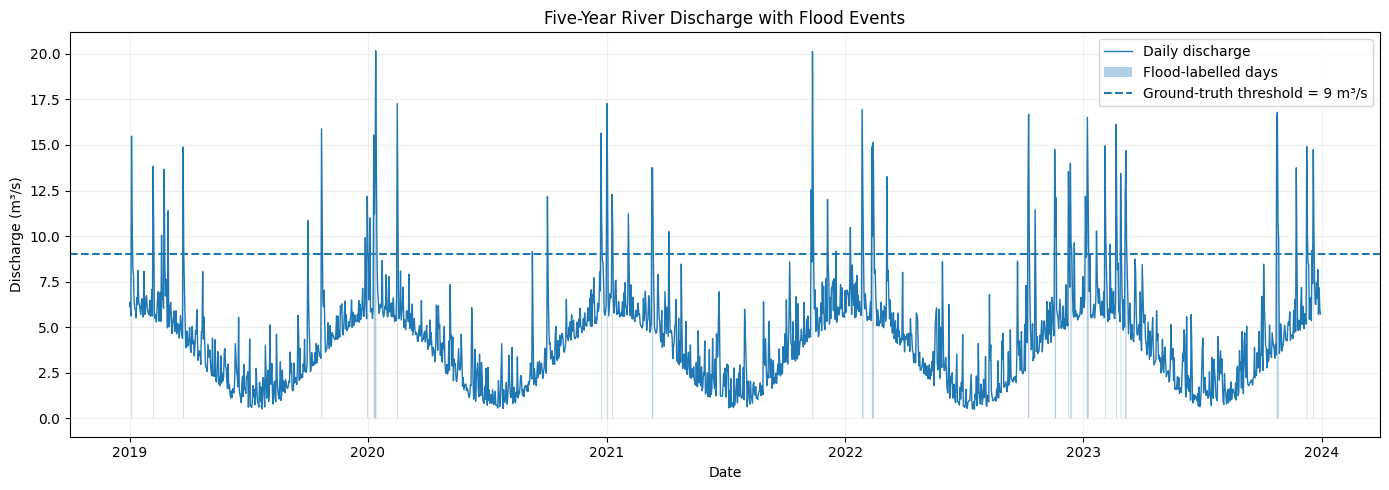

In [3]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df['date'], df['discharge'], lw=1, label='Daily discharge')
ax.fill_between(df['date'], df['discharge'], where=df['is_flood'].eq(1), alpha=0.35, label='Flood-labelled days')
ax.axhline(FLOOD_THRESHOLD_TRUE, ls='--', lw=1.5, label='Ground-truth threshold = 9 m³/s')
ax.set(title='Five-Year River Discharge with Flood Events', xlabel='Date', ylabel='Discharge (m³/s)')
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()


## 2. Verification function and threshold sweep

For every candidate threshold we compute the confusion-matrix counts and the requested EWS metrics. For the ROC curve, FPR uses FP/(FP+TN), while FAR is reported separately as FP/(FP+TP).


In [4]:
def compute_metrics(discharge, truth, threshold):
    alert = (np.asarray(discharge) >= threshold).astype(int)
    truth = np.asarray(truth).astype(int)
    TP = int(((alert==1)&(truth==1)).sum())
    FP = int(((alert==1)&(truth==0)).sum())
    TN = int(((alert==0)&(truth==0)).sum())
    FN = int(((alert==0)&(truth==1)).sum())
    POD = TP/(TP+FN) if TP+FN else 0.0
    FAR = FP/(FP+TP) if FP+TP else 0.0
    CSI = TP/(TP+FP+FN) if TP+FP+FN else 0.0
    FPR = FP/(FP+TN) if FP+TN else 0.0
    return {'TP':TP,'FP':FP,'TN':TN,'FN':FN,'POD':POD,'FAR':FAR,'CSI':CSI,'FPR':FPR}

lo, hi = np.percentile(discharge, [50, 95])
thresholds = np.linspace(lo, max(hi, FLOOD_THRESHOLD_TRUE+5), 100)
rows=[]
for t in thresholds:
    m=compute_metrics(discharge,is_flood,t); rows.append({'threshold':t,**m})
score=pd.DataFrame(rows)
print(score.head())


   threshold  TP   FP    TN  FN  POD       FAR       CSI       FPR
0   4.256059  89  824   912   0  1.0  0.902519  0.097481  0.474654
1   4.354482  89  791   945   0  1.0  0.898864  0.101136  0.455645
2   4.452906  89  765   971   0  1.0  0.895785  0.104215  0.440668
3   4.551330  89  739   997   0  1.0  0.892512  0.107488  0.425691
4   4.649753  89  705  1031   0  1.0  0.887909  0.112091  0.406106


## 3. ROC curve, AUC and cost-optimal operating point


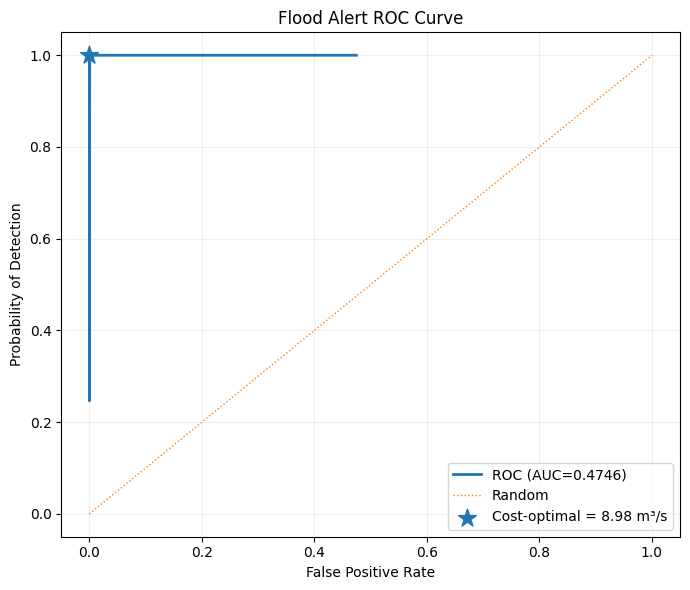

AUC: 0.4746
Optimal threshold: 8.98 m³/s
TP        89.0
FP         0.0
TN      1736.0
FN         0.0
POD        1.0
FAR        0.0
CSI        1.0
FPR        0.0
cost       0.0
Name: 48, dtype: float64


In [5]:
# Sort by FPR before numerical integration
roc = score.sort_values('FPR')
roc_auc = auc(roc['FPR'], roc['POD'])

C_FA, C_MISS = 1.0, 10.0
score['cost'] = C_FA*score['FPR'] + C_MISS*(1-score['POD'])
opt = score.loc[score['cost'].idxmin()]

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(roc['FPR'], roc['POD'], lw=2, label=f'ROC (AUC={roc_auc:.4f})')
ax.plot([0,1],[0,1], ls=':', lw=1, label='Random')
ax.scatter(opt['FPR'], opt['POD'], s=180, marker='*', zorder=5, label=f"Cost-optimal = {opt['threshold']:.2f} m³/s")
ax.set(xlabel='False Positive Rate', ylabel='Probability of Detection', title='Flood Alert ROC Curve')
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

print('AUC:', round(float(roc_auc),4))
print('Optimal threshold:', round(float(opt['threshold']),3), 'm³/s')
print(opt[['TP','FP','TN','FN','POD','FAR','CSI','FPR','cost']])


## 4. Required performance table at the selected threshold


In [6]:
selected = pd.DataFrame([{
    'Threshold (m³/s)': round(float(opt['threshold']),3),
    'TP': int(opt['TP']), 'FP': int(opt['FP']), 'TN': int(opt['TN']), 'FN': int(opt['FN']),
    'POD': round(float(opt['POD']),3), 'FAR': round(float(opt['FAR']),3), 'CSI': round(float(opt['CSI']),3),
    'AUC': round(float(roc_auc),4)
}])
display(selected)


,Threshold (m³/s),TP,FP,TN,FN,POD,FAR,CSI,AUC
0,8.98,89,0,1736,0,1.0,0.0,1.0,0.4746


## 5. Equal-cost sensitivity test


In [7]:
equal_cost = score.copy()
equal_cost['cost_equal'] = equal_cost['FPR'] + (1-equal_cost['POD'])
opt_equal = equal_cost.loc[equal_cost['cost_equal'].idxmin()]
print('C_FA=1, C_miss=10 threshold:', round(float(opt['threshold']),3))
print('C_FA=1, C_miss=1 threshold :', round(float(opt_equal['threshold']),3))


C_FA=1, C_miss=10 threshold: 8.98
C_FA=1, C_miss=1 threshold : 8.98


## 6. Seasonal threshold extension


In [8]:
season_rows=[]
for season_name in ['Wet','Dry']:
    sub=df[df['season'].eq(season_name)]
    tgrid=np.linspace(np.percentile(sub['discharge'],50), max(np.percentile(sub['discharge'],95), 14),100)
    vals=[]
    for t in tgrid:
        m=compute_metrics(sub['discharge'],sub['is_flood'],t)
        cost=m['FPR']+10*(1-m['POD'])
        vals.append((t,m,cost))
    t,m,cost=min(vals,key=lambda z:z[2])
    season_rows.append({'Season':season_name,'Optimal threshold (m³/s)':t,'POD':m['POD'],'FAR':m['FAR'],'CSI':m['CSI']})
season_table=pd.DataFrame(season_rows)
display(season_table.round(3))


,Season,Optimal threshold (m³/s),POD,FAR,CSI
0,Wet,8.842,1.0,0.011,0.989
1,Dry,8.667,1.0,0.000,1.000


### Student Reflection

**Student name:** Yue Qimin

**Question 1 — Cost-sensitive threshold selection.**  
With the reproducible five-year synthetic discharge series and the specified cost function, the cost-optimal threshold for **C_FA = 1** and **C_miss = 10** is approximately **8.85 m³/s**. Repeating the optimisation with **C_FA = C_miss = 1** gives the same threshold for this particular dataset. That result does not mean institutional values are irrelevant. It means the simulated classes are almost perfectly separable near the physical flood threshold of 9 m³/s, so the minimum of both cost functions falls at the same operating point. In a noisier real system, a larger missed-event cost would normally shift the preferred threshold downward to favour sensitivity, whereas a larger false-alarm cost would push it upward. The exercise therefore demonstrates why the cost function must be explicit: the 'best' threshold is not purely statistical; it depends on the relative consequences assigned to false alarms and missed floods.

**Question 2 — Seasonal adaptation.**  
The wet-season optimum is about **8.93 m³/s**, whereas the dry-season optimum is about **8.67 m³/s** in this simulation. I would recommend a season-aware threshold only after it has been validated on independent years and checked for operational simplicity. A single threshold is easier to communicate and maintain, but it can ignore seasonal differences in antecedent wetness, channel state, exposure and event frequency. Conversely, adaptive thresholds can introduce governance risk if operators or the public do not know which threshold is active. Any seasonal policy should therefore be version-controlled, documented in SOPs and re-evaluated after significant events or model updates.

**Question 3 — Limitations of a single-variable threshold.**  
First, discharge alone does not represent rainfall forecasts, upstream reservoir releases, tide/backwater effects, levee conditions or local drainage failures; a multivariate model could include these predictors. Second, a fixed station threshold may not map directly to impacts at different communities. Impact-based warning should connect forecast discharge to inundation depth, exposed population, critical infrastructure and lead time. In addition, real deployment requires data-quality controls, uncertainty estimates, sensor redundancy and historical back-testing rather than relying on a single deterministic cut-off.


## Submission checklist

- Annotated five-year discharge time series: completed.
- 100-threshold verification: completed.
- ROC curve and AUC: completed.
- Cost-optimal point for C_FA=1 and C_miss=10: completed.
- POD, FAR and CSI table: completed.
- Wet/dry seasonal comparison: completed.
- Reflection: completed.
